In [22]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Employee_ID": [101, 102, 103, 104, 105, 106],
    "Department": ["Sales", "HR", "IT", "IT", "Finance", "Sales"],
    "Age": [24, 26, 25, 27, 26, 25],
    "Experience_Years": [1, 2, 2, 3, 2, 1],
    "Salary": [28000, 1000, 29000, 31000, 12000, 150000],  # Outliers
    "Performance_Score": [68, 72, 70, 74, 71, 73]
})

df

,Employee_ID,Department,Age,Experience_Years,Salary,Performance_Score
0,101,Sales,24,1,28000,68
1,102,HR,26,2,1000,72
2,103,IT,25,2,29000,70
3,104,IT,27,3,31000,74
4,105,Finance,26,2,12000,71
5,106,Sales,25,1,150000,73


----------------

### **Outliers**
- It is the data point that is far different from other data points in the dataset.
- Handling them is crucial otherwise the result which we will get might be incorrect.

### **To Check Outliers**

#### **Method 1: Using Box Plot**

{'whiskers': [<matplotlib.lines.Line2D at 0x20ddcbb9a50>,
 'caps': [<matplotlib.lines.Line2D at 0x20ddcbbb050>,
 'boxes': [<matplotlib.lines.Line2D at 0x20ddcb07a50>],
 'medians': [<matplotlib.lines.Line2D at 0x20ddcb79790>],
 'fliers': [<matplotlib.lines.Line2D at 0x20ddcbcce10>],
 'means': []}

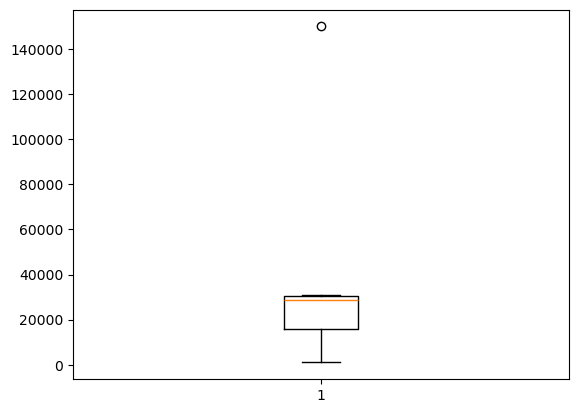

In [10]:
import matplotlib.pyplot as plt

plt.boxplot(df["Salary"])

#### **Method 2: Using Histogram**

(array([2., 2., 1., 0., 0., 0., 0., 0., 0., 1.]),
 array([  1000.,  15900.,  30800.,  45700.,  60600.,  75500.,  90400.,
        105300., 120200., 135100., 150000.]),
 <BarContainer object of 10 artists>)

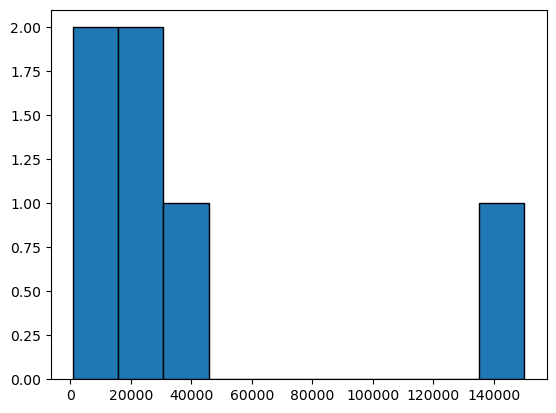

In [12]:
plt.hist(df["Salary"], edgecolor='black')

#### **Method 3: Using IQR (Inter Quartile Range)**

In [18]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

df[(df["Salary"] < lower_bound)|(df["Salary"] > upper_bound)]

,Employee_ID,Department,Age,Experience_Years,Salary,Performance_Score
5,106,Sales,25,1,150000,73


------------------

### **Handling Outliers**
#### **Method 1: Using IQR (Inter Quartile Range)**
- **Use When:**
- Data is skewed
- Data has extreme values
- Data is not normally distributed
- You want a robust method

##### **A. Trimming**
- It will be used if we are having large dataset in that if we remove rows that contains ouliers.
- It will not make much differences on Whole dataset.
- In this case we can remove the rows which has outliers that is called as **Trimming**

In [25]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

df[(df["Salary"] > lower_bound)&(df["Salary"] < upper_bound)]

# Here it will only include data point that lies between lower_bound and upper_bound.
# Other data points will be removed.

,Employee_ID,Department,Age,Experience_Years,Salary,Performance_Score,New_Salary
0,101,Sales,24,1,28000,68,28000.0
1,102,HR,26,2,1000,72,1000.0
2,103,IT,25,2,29000,70,29000.0
3,104,IT,27,3,31000,74,31000.0
4,105,Finance,26,2,12000,71,12000.0


##### **B. Capping / Winsorization**
- If the dataset is smaller and if we remove rows that contains outliers it will affect whole dataset.
- In this case we can 2 two things:
- One is: If the datapoint is lower than lower_bound replace that with lower_bound
- Second is: If the datapoint is bigger than upper_bound replace that with upper_bound

In [26]:
df["New_Salary"] = np.where(df["Salary"] < lower_bound, lower_bound, np.where(df["Salary"] > upper_bound, upper_bound, df["Salary"]))
df

,Employee_ID,Department,Age,Experience_Years,Salary,Performance_Score,New_Salary
0,101,Sales,24,1,28000,68,28000.0
1,102,HR,26,2,1000,72,1000.0
2,103,IT,25,2,29000,70,29000.0
3,104,IT,27,3,31000,74,31000.0
4,105,Finance,26,2,12000,71,12000.0
5,106,Sales,25,1,150000,73,52250.0


#### **Method 2: Z - Score**

- Data is normally distributed (bell curve)
- No strong skewness
- Mean & standard deviation represent data well
- You want a statistical distance from mean

In [27]:
mean = df['Salary'].mean()
std = df['Salary'].std()

df['z_score'] = (df['Salary'] - mean) / std
df

,Employee_ID,Department,Age,Experience_Years,Salary,Performance_Score,New_Salary,z_score
0,101,Sales,24,1,28000,68,28000.0,-0.254858
1,102,HR,26,2,1000,72,1000.0,-0.752292
2,103,IT,25,2,29000,70,29000.0,-0.236434
3,104,IT,27,3,31000,74,31000.0,-0.199588
4,105,Finance,26,2,12000,71,12000.0,-0.549633
5,106,Sales,25,1,150000,73,52250.0,1.992805


In [29]:
outliers = df[abs(df['z_score']) <= 3]
outliers
# In this above example Z - score is not Preferred Because outlier is much higher

,Employee_ID,Department,Age,Experience_Years,Salary,Performance_Score,New_Salary,z_score
0,101,Sales,24,1,28000,68,28000.0,-0.254858
1,102,HR,26,2,1000,72,1000.0,-0.752292
2,103,IT,25,2,29000,70,29000.0,-0.236434
3,104,IT,27,3,31000,74,31000.0,-0.199588
4,105,Finance,26,2,12000,71,12000.0,-0.549633
5,106,Sales,25,1,150000,73,52250.0,1.992805


----------------